In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
   # for filename in filenames:
       # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Below are the packages I have used for loading the data into Pytorch,and the nueral network package to define the Structure later. Seaborn and Matplotlib are also loaded so that the loss and accuracy for the training and validation sets across epochs cam be visualised

In [2]:
#imports for creating data set 
import torch 

from torchvision import datasets, transforms # allows us to standardise the images 
from torch.utils.data import Subset,DataLoader # allows the loading of data, 
#and us to create a subset which makes all catagories have the same number of images  
import kornia.augmentation as K # used for data augmentation on gpu 

# Imports for creating nueral network 
import torch.nn as nn 

#Imports for visualisation 
#pandas is also used to create a dataframe which the metrics are added to
import matplotlib as plt

import seaborn as sns

In [3]:
device = torch.device("cuda") # used to speed up training loop

In [4]:
#Defining image transforms 
transform = transforms.Compose([
    transforms.Resize((300,300)),# ensures all images are the same size 
    #( 300 by 300 is the  dominant image size in the data set )
    
    transforms.ToTensor()
])



The Dataset I am loading in is based off of Michael Kerr's "20k Album Covers within 20 Genres", linked here: [dataset](https://www.kaggle.com/datasets/michaeljkerr/20k-album-covers-within-20-genres) 

The following adjustments were made to the base dataset :

-I have removed the record sleeve images from all catagories, because of the lack of difference in their look across genres, which could ( articulation)

-the catagories of Soul,Grime,Drum and Bass and Techno were removed. 

This is becuase a large portion of their images were record sleeves. While this is understandable, for example becuase many Drum and Bass Track never had formal album releases and where mostly club mixes, it meant they had a sparser set of images for the model to learn from 

-Duplicate images within genre folders were removed, to prevent the model overfitting to certain images.

In [5]:
# loading in the base dataset and applying image transform

base_dataset = datasets.ImageFolder(root="/kaggle/input/datasets/marcusdarrell/trimmed-album-covers-set/GAID- trimmed set"
                           ,transform=transform)
print("Dataset loaded")

Dataset loaded


In [6]:
#checking mapping for base dataset 

print(base_dataset.class_to_idx)

{'Blues': 0, 'Classical': 1, 'Country': 2, 'DeathMetal': 3, 'DoomMetal': 4, 'Electronic': 5, 'Folk': 6, 'HeavyMetal': 7, 'HipHop': 8, 'Jazz': 9, 'LoFi': 10, 'Pop': 11, 'PsychedelicRock': 12, 'Punk': 13, 'Reggae': 14, 'Rock': 15}


In [7]:
# grouping images by genre to then enable stratified sampling 

class_indices = [[] for x in range(16)] # creates 16 blank lists 

for idx, (path, label) in enumerate(base_dataset.samples):
    class_indices[label].append(idx) # appends path

After trimming down the sets, there was an uneven number of images in each. In order to not have the model overly value 1 genre over the other, I limited the max number of images taken to be 880. This was the highest number of imags present in each genre, that still split evenly for train, validation and test sets.

In [8]:
# Limiting the number of images taken form each set 
max_per_class = 880

balanced_class_indices = []

for indices in class_indices:
    balanced_class_indices.append(indices[:max_per_class])

I chose an 80 - 10 - 10 split for my train, validation and test sets, as it

In [9]:
# splitting into train validation and test sets 
# sets for each
train_indices = []
val_indices = []
test_indices = []

for indices in balanced_class_indices:


    n = len(indices)

    train_end = int(0.8 * n) # first 80%
    val_end = int(0.9 * n) # 80% to 90%

    train_indices.extend(indices[:train_end])
    val_indices.extend(indices[train_end:val_end])
    test_indices.extend(indices[val_end:]) # 90 % to 100%

In [10]:
# wrapping indicies in subset for loading of dataset 
train_dataset = Subset(base_dataset, train_indices)
val_dataset = Subset(base_dataset, val_indices)
test_dataset = Subset(base_dataset, test_indices)

In [11]:
# Writing the loaders for each loader 

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True # means each batch will have a mix of genres 

)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

When beginning to create the CNN I made several choices for a baseline

4 convolutional layers: 32-64-128-256

with each convolution layer, a batch normalisation layer was used, and ReLU was used as the activation unit 


dropout layer for the classifier
and global average pooling 



In [12]:


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolutional layers
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(in_channels=3, out_channels=32,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

    
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

    
    
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.1), # 1st dropout 
          

            # Block 3
            nn.Conv2d(64, 128,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            
            nn.MaxPool2d(kernel_size=2),
            
          
            # Block 4
            nn.Conv2d(128, 256,
                      kernel_size=3, padding=1),
        
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(0.15), # 2nd dropout 
            
            #Block 5 
            nn.Conv2d(256, 512,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # block 6 

                 nn.Conv2d(512, 1024,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            
            

    
        )
         

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(1024, 16)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)

        return x # returns model probablities of the images being part of each respective genre

In [13]:
#defining training and validation loop

def train_loop(model,loader,loss_func, optimizer,device):
    model.train()

    #variables to keep track 
    running_loss=0
    correct=0 # number of correct predictions 
    total=0 # number of total preditions , used to calculate accuracy score 

    for images,labels in loader:

        images = images.to(device)# sends images and labels to GPU 
        labels = labels.to(device)
        
        optimizer.zero_grad()# resets the gradient for each batch of images 
        
        outputs= model(images) # passes the batch of images through the model 
    
        # calculating loss 
        loss=loss_func(outputs,labels) 
    
        #backpropagation
        loss.backward()
        
        # update weights 
        optimizer.step()
    
        # record loss 
        running_loss= running_loss + loss.item() # .item converts loss from a tensor into a number 
        
        values, predicted=torch.max(outputs, 1) # saves the index of the highest value in each tensor ( which is the predicted album genre)
        
            # counts correct predictions 
        
        correct=correct+ (predicted == labels).sum().item() # number of correctly classified images
        
            # counts total images passed through
        
        total = total + labels.size(0)
            
    accuracy = 100 * correct / total
        
    return running_loss,accuracy
def eval_loop(model,loader,loss_func,device):
    model.eval()
    
    correct = 0
    total = 0
    running_loss = 0
    
    with torch.no_grad():
    
        for images, labels in loader:
            
            images = images.to(device)
            
            labels = labels.to(device)
            
            outputs = model(images)
    
            loss = loss_func(outputs, labels)
    
            running_loss += loss.item()
    
            values , predicted = torch.max(outputs, 1)
    
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return running_loss,accuracy

Changelog of model tuning 

1st run ( 20 epochs, 0.001 learning rate): achieved 21% accuracy on both train and validation.


2nd run(20 epochs,0.002 learning rate): acheived 21 % training and 20% on validation

3rd run (20 epochs 0.001 learning rate): Added another convolutional block to the model : 256 to 512  max train of 26% and validation of 23%

4th run ( 20 epochs 0.001) Increased chance of dropout layer to 0.3 25% training, 24% eval accuracy 

5th run(20 epochs variable learning rate)  Used reduce Lr on plateau as scheduler: base value of 0.001, factor of 0.25 and patience of 2 epochs. 28 % train and 26% validation 

6th run (20 epochs variable leanring rate) added dropout layers to blocks 2 through 5 starting at 0.1 and increasing by 0.05 each time  20% train and 24% validation 

7th run ( 20 epochs variable learning rate) removed dropouts specified above, added another block
512 to 1024 43% train acc and 29 eval acc 

8th run ( 50 epochs variable learning rate) added in dropouts: layers 2,4,6 with values 0.1,0.15 and 0.2 respectively 42 train 28 eval 

9th run ( 50 epochs, varaible learning rates) Added weight decay of 0.0001 to Adam optimiser 33 train 27 eval 

10th run ( 50 epochs variable learning rate) increased dropout to 0.15,0.2, 0.25 and 0.3 respectively 36 27

11th run ( 50 epochs variable learning rate) decreased dropout back to 8th run and changed optimiser to AdamW 37 train 29 eval

12th run ( 50 epochs variable learning rate) decreased initial learning rate to 0.0003 39 train 28 eval 

13th run ( 50 epochs variable learning rate) removed 512 -1024 block, stacked convolutional layers for 32,64,128 and 256 24 train 25 eval

14th run(50 epochs variable learning rate) reset model structure to 6 blocks as in 12th run 39 train 27 eval

15th run(50 epochs variable learning rate) used random horizontal flip on training data set p=0.5 and colour jiggle with all parameters ( brightness, contrast, saturation, hue) set to 0.2 and probability to 0.5 Train 49 28 eval

16th run(50 epochs variable learning rate) removed data augmentation defined above in 15th run  train 39 28 eval

17( 100 epochs variable learning rate) increase to 100 epochs 55 train 30 epoch 

18th run ( 100 epochs variable learning rate) change base learning rate to 0.0015 and change the factor for reducle LR on plateau to 0.75 80 train 27 eval 

19th run ( 100 epochs variabe learning rate) reduce base learning rate to 0.00125 and reduce factor to 0.5  65 train 27 eval 

20th run ( 100 epochs variable learning rate) reset learning rate to 0.001 and factor to 0.25 36 trainv 27 eval 

21 run (100 epochs variable learning rate) increased wieght decay to 0.000101 36 train 26 eval 

22 run ( 100 epochs variable learning rate)  decreased factor to 0.125 decreased patience to 1 31 train 26 eval 

23 run( 100 epochs, variable learning rate) increased base learning rate to 0.00105 31 train 27 test 

24th run ( 100 epochs variable learning rate) decreased factor to 0.1 and increased patience to 2
train 38 validation 27 

25th run ( 100 epochs variable learning rate) increased factor to 0.5, patience to 5 and added a cooldown of 1 epoch to the schedular  94 train 29 eval (99th epoch before crash)

Epoch 1/100
Training Loss: 1000.8145871162415
Training Accuracy: 9.206321022727273%
Evaluation Loss: 119.23612022399902
Evaluation Accuracy: 13.707386363636363%
Epoch 2/100
Training Loss: 966.2314264774323
Training Accuracy: 11.381392045454545%
Evaluation Loss: 114.91306042671204
Evaluation Accuracy: 14.204545454545455%
Epoch 3/100
Training Loss: 939.9130337238312
Training Accuracy: 13.893821022727273%
Evaluation Loss: 121.21045756340027
Evaluation Accuracy: 11.008522727272727%
Epoch 4/100
Training Loss: 918.6214430332184
Training Accuracy: 15.269886363636363%
Evaluation Loss: 111.11084616184235
Evaluation Accuracy: 19.03409090909091%
Epoch 5/100
Training Loss: 907.3790566921234
Training Accuracy: 16.583806818181817%
Evaluation Loss: 111.48132872581482
Evaluation Accuracy: 15.340909090909092%
Epoch 6/100
Training Loss: 895.3444809913635
Training Accuracy: 17.96875%
Evaluation Loss: 113.39958167076111
Evaluation Accuracy: 17.68465909090909%
Epoch 7/100
Training Loss: 886.9817161560059
T

<Axes: xlabel='epochs', ylabel='train_accuracy'>

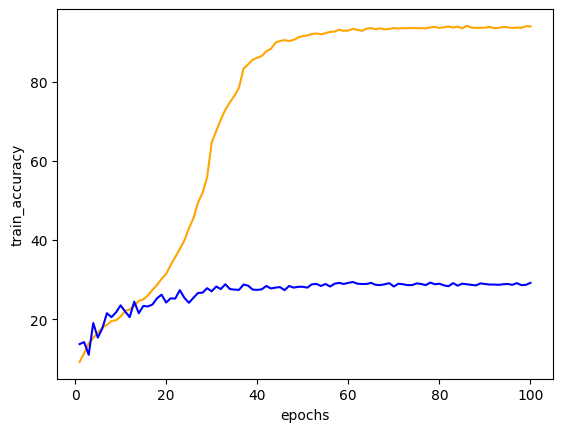

In [14]:
# creating an instance of the model

model=CNN().to(device)

#print(model)

# defining the optimiser and loss function 

loss_func = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
     weight_decay=0.0001
)

# defining scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5, 
    patience=5,
    cooldown=1
)

# running model 
num_epochs=100
# creating array for accuracy and lost to graphs can be used to better visualise fluctuations
epochs=[]
train_acc_arr=[]
train_loss_arr=[]
eval_acc_arr=[]
eval_loss_arr=[]
lrs=[]

best_acc=0.0 # sets running maximum to 0
# writing training loop 
for epoch in range(num_epochs):
    train_loss, train_acc = train_loop(
        model,
        train_loader,
        loss_func,
        optimizer,
        device)
    
    eval_loss,eval_acc= eval_loop(
        model,
        val_loader,
        loss_func,
        device)
    scheduler.step(eval_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Training Loss: {train_loss}")

    print(f"Training Accuracy: {train_acc}%")

    print(f"Evaluation Loss: {eval_loss}")

    print(f"Evaluation Accuracy: {eval_acc}%")
    #adding the epoch metrics to arrays for visualisation
    epochs.append(epoch+1)
    train_acc_arr.append(train_acc)
    train_loss_arr.append(train_loss)
    eval_acc_arr.append(eval_acc)
    eval_loss_arr.append(eval_loss)
    lrs.append(scheduler.get_last_lr()[0])
metrics = pd.DataFrame({
    "epochs": epochs,
    "train_accuracy": train_acc_arr,
    "train_loss": train_loss_arr,
    "val_accuracy": eval_acc_arr,
    "val_loss": eval_loss_arr,
    "lr": lrs
})
sns.lineplot(data=metrics,x="epochs",y="train_accuracy", color="orange")
sns.lineplot(data=metrics,x="epochs",y="val_accuracy",color="blue")


In [15]:
 torch.save(model.state_dict(), "/kaggle/working/model.pt")

<Axes: xlabel='epochs', ylabel='lr'>

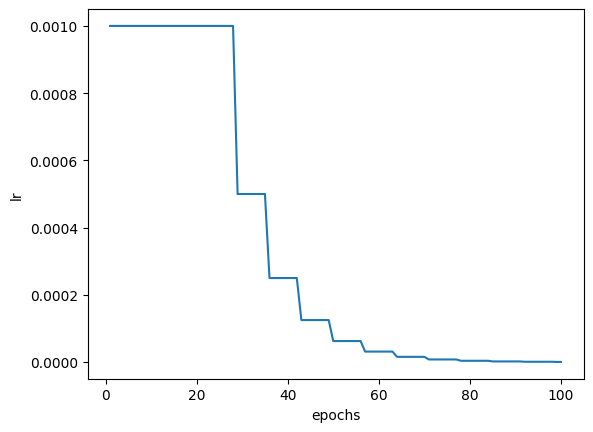

In [16]:
sns.lineplot(data=metrics,x="epochs",y="lr")

<Axes: xlabel='epochs', ylabel='train_loss'>

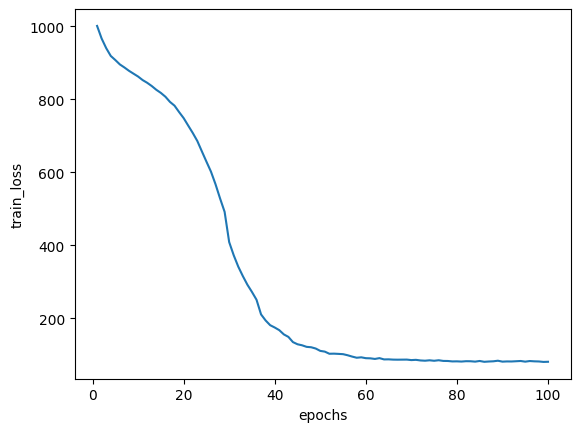

In [17]:


sns.lineplot(data=metrics,x="epochs",y="train_loss")
#sns.lineplot(data=metrics,x="epochs",y="val_loss")

<Axes: xlabel='epochs', ylabel='train_accuracy'>

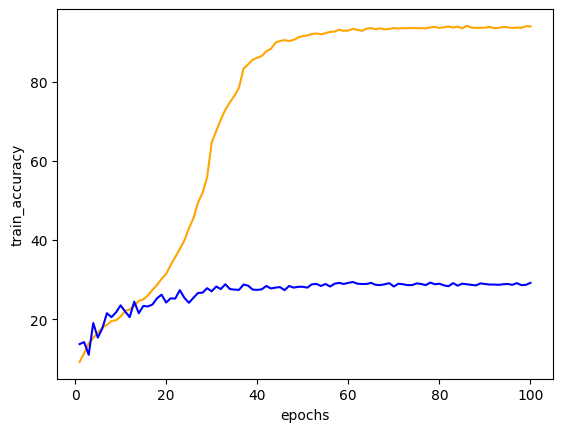

In [18]:
sns.lineplot(data=metrics,x="epochs",y="train_accuracy", color="orange")
sns.lineplot(data=metrics,x="epochs",y="val_accuracy",color="blue")

<Axes: xlabel='lr', ylabel='val_accuracy'>

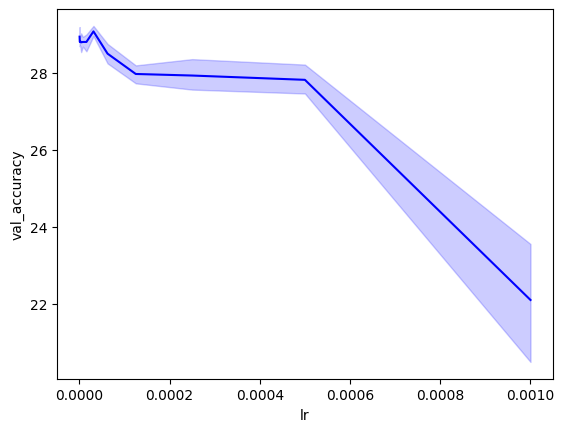

In [19]:
sns.lineplot(data=metrics,x="lr",y="val_accuracy",color="blue")